# 🤖 Week 3 — Day 1: Supervised Learning Concepts & the Scikit-learn API

**BinX Tech — AI & Machine Learning Internship Program**

![status](https://img.shields.io/badge/status-in--progress-yellow)
![phase](https://img.shields.io/badge/phase-2%20%7C%20Core%20ML%20Training-9146FF)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-Scikit--learn%20%7C%20Pandas%20%7C%20Matplotlib-orange)

---

| | |
|---|---|
| **Day** | Day 1 of 5 — first day of Phase 2 |
| **Duration** | 8 hours |
| **Tools** | Scikit-learn • Pandas • Matplotlib • Jupyter Notebook |
| **Prerequisite** | Weeks 1–2 completed |

---

## 🎯 Learning Objectives

- Explain what supervised learning is and distinguish regression from classification.
- Separate a dataset into features (X) and target (y).
- Perform a train/test split and explain why evaluating on unseen data is essential.

---

## 💡 Why This Week Is Different

Every previous week analyzed data. This week, for the first time, we **train models that make
predictions**. Everything from Week 1 (reproducibility) and Week 2 (EDA, statistics) now feeds
directly into building something that learns patterns and generalizes to new data.

---


## 🔧 Step 0 — Environment Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📖 Step 1 — What Is Supervised Learning?

Supervised learning trains a model on **labeled examples** — data where the correct answer (the
target) is already known — so it can predict that answer for new, unseen data. "Supervised" means
every training example comes with its correct label, like a teacher's answer key.

## 🔀 Step 2 — Regression vs. Classification

The two types of supervised learning are distinguished entirely by what the target looks like:

| | Regression | Classification |
|---|---|---|
| **Predicts** | A continuous number | A category / class |
| **Example** | House price, temperature, income | Spam/not spam, churn/stay |
| **Metric** | RMSE, MAE, R² | Accuracy, precision, recall, F1 |
| **This week** | Day 2 | Days 3–4 |

---


## 📂 Step 3 — Load a Real Dataset

We'll use the **Diamonds** dataset (already familiar from Week 2) to demonstrate a regression
setup: predicting `price` from a diamond's physical properties.


In [3]:
df = sns.load_dataset("diamonds")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 🎯 Step 4 — Features (X) and Target (y)

The inputs are the **features (X)** — the columns the model learns from. The output being
predicted is the **target (y)** — the column of correct answers. The entire task of supervised
learning is learning the relationship between X and y from training data.


In [4]:
# Using only numeric features for this first demonstration
feature_cols = ["carat", "depth", "table", "x", "y", "z"]

X = df[feature_cols]
y = df["price"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:  ", y.shape)
X.head()


Features (X) shape: (53940, 6)
Target (y) shape:   (53940,)


,carat,depth,table,x,y,z
0,0.23,61.5,55.0,3.95,3.98,2.43
1,0.21,59.8,61.0,3.89,3.84,2.31
2,0.23,56.9,65.0,4.05,4.07,2.31
3,0.29,62.4,58.0,4.20,4.23,2.63
4,0.31,63.3,58.0,4.34,4.35,2.75


### 📝 Interpretation

*(Fill this in — why is `price` the target here and not a feature? What would happen if we
accidentally included it in X?)*

---

## ✂️ Step 5 — The Train/Test Split

**The single most important rule in ML:** never evaluate a model on the same data it was trained
on. A model can memorize its training data and look perfect, yet fail completely on new data.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)
print(f"\nTrain set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set:  {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")


X_train shape: (43152, 6)
X_test shape:  (10788, 6)
y_train shape: (43152,)
y_test shape:  (10788,)

Train set: 43152 samples (80.0%)
Test set:  10788 samples (20.0%)


### 🎨 Visualizing the Split — Donut Chart


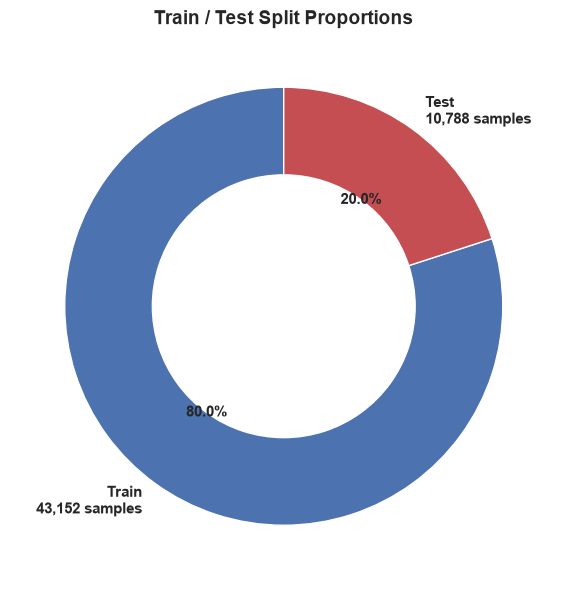

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
sizes = [len(X_train), len(X_test)]
labels = [f"Train\n{len(X_train):,} samples", f"Test\n{len(X_test):,} samples"]
colors = ["#4C72B0", "#C44E52"]

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=90, wedgeprops=dict(width=0.4, edgecolor="white"),
    textprops={"fontsize": 11, "fontweight": "bold"}
)
ax.set_title("Train / Test Split Proportions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 🎨 Visualizing the Split — Spatially, on the Data Itself

This is the more powerful visualization: instead of just showing proportions, we can see **which
actual data points** ended up in train vs. test — confirming the split is a genuine random sample,
not, say, all the cheapest diamonds in test and all the expensive ones in train.


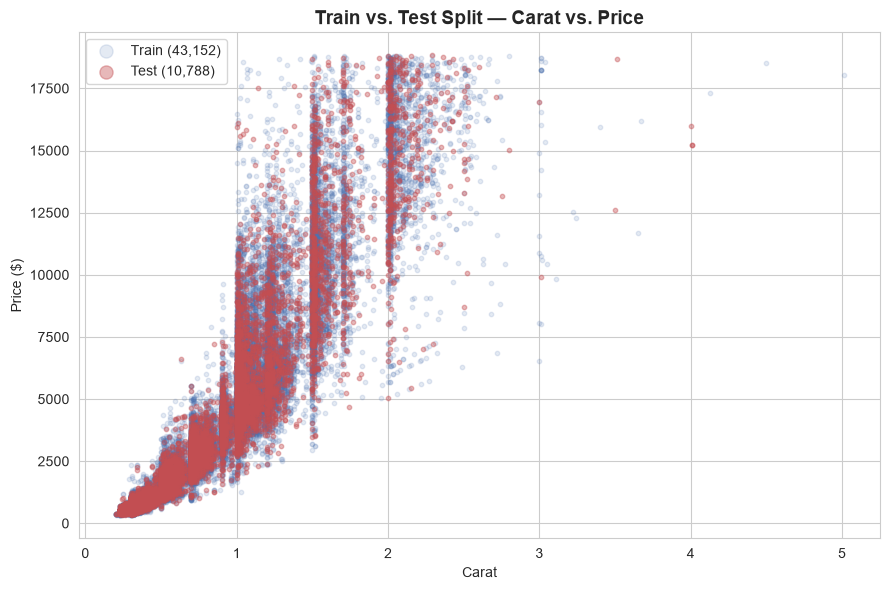

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X_train["carat"], y_train, alpha=0.15, s=10, color="#4C72B0", label=f"Train ({len(X_train):,})")
ax.scatter(X_test["carat"], y_test, alpha=0.4, s=10, color="#C44E52", label=f"Test ({len(X_test):,})")

ax.set_title("Train vs. Test Split — Carat vs. Price", fontsize=14, fontweight="bold")
ax.set_xlabel("Carat")
ax.set_ylabel("Price ($)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


**What this shows:** *(fill in — do the train and test points appear evenly mixed across the
whole range of carat and price, or does one set look concentrated in a particular region? What
would it mean if the test set only contained the smallest diamonds?)*

---

## ⚙️ Step 6 — The Scikit-learn API: One Interface, Every Model

Scikit-learn's greatest strength is a **consistent API** — every model, no matter how different
internally, is used through the same four steps:

| Step | Method | What It Does |
|---|---|---|
| 1. Instantiate | `model = Model()` | Create the model, set its options |
| 2. Fit | `model.fit(X_train, y_train)` | Learn patterns from training data |
| 3. Predict | `model.predict(X_test)` | Predict on new data |
| 4. Score | `model.score(X_test, y_test)` | Evaluate performance |

Learn it once, and you can use **every model in the library** with this same pattern — a preview
of Day 2 (Linear Regression).

---

## ✅ Step 7 — Confirm Everything Is Ready


In [8]:
assert X_train.shape[0] == y_train.shape[0], "Mismatch between X_train and y_train!"
assert X_test.shape[0] == y_test.shape[0], "Mismatch between X_test and y_test!"
assert X_train.shape[1] == X_test.shape[1], "Feature count mismatch between train and test!"

print("All shape checks passed ✅")
print("Ready to train a model in Day 2.")


All shape checks passed ✅
Ready to train a model in Day 2.


### 📝 Why the Model Must Never See the Test Set During Training

*(Write your own explanation here — in your own words, why would training on the test set make
the evaluation dishonest? Think back to the "memorization vs. generalization" idea.)*

---

## ✅ Key Takeaways

*(Write 3–5 sentences on what this notebook demonstrated: features vs. target, why the train/test
split matters, and what you observed in the spatial visualization of the split.)*

- ...
- ...
- ...

---

## 📚 Resources

| Resource | Type | Focus |
|---|---|---|
| [Supervised Learning Concepts (Video)](https://www.youtube.com/watch?v=0B5eIE_1vpU) | Video | Core concepts covered today |
| [Scikit-learn Documentation](https://scikit-learn.org/stable/) | Docs | Official API reference |

---

## ✍️ Author

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 3, Day 1 — Supervised Learning Concepts & the Scikit-learn API

---

## 🔗 Next Step

Proceed to **Day 2 — Linear Regression**
